In [356]:
import pandas as pd
import numpy as np

In [357]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [358]:
import seaborn as sns

In [359]:
df = pd.read_csv("upi_transactions_mixed_upi_dataset.csv")

In [360]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87342 entries, 0 to 87341
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   receiver_upi_id          87342 non-null  object
 1   transaction_type         87342 non-null  object
 2   transaction_time(HH:MM)  87342 non-null  object
 3   date(DD/MM/YYYY)         87342 non-null  object
 4   amount(Rs.)              87342 non-null  int64 
 5   Fraud                    87342 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.0+ MB


In [361]:
df.isnull().sum()

receiver_upi_id            0
transaction_type           0
transaction_time(HH:MM)    0
date(DD/MM/YYYY)           0
amount(Rs.)                0
Fraud                      0
dtype: int64

In [362]:
df.head(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),date(DD/MM/YYYY),amount(Rs.),Fraud
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,No
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,Yes
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,Yes
3,kycgee@upi,Requested,03:43,30/10/2021,160373,Yes
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,Yes
5,supportgsx@secure,Requested,18:56,18/07/2020,143828,Yes
6,bharatpe@okhdfc,Debited,05:19,14/05/2017,131115,No


In [363]:
df.columns.tolist()

['receiver_upi_id',
 'transaction_type',
 'transaction_time(HH:MM)',
 'date(DD/MM/YYYY)',
 'amount(Rs.)',
 'Fraud']

In [364]:
df["Fraud"] = df["Fraud"].map({"No":0,"Yes":1})

In [365]:
df['Fraud'].value_counts()

Fraud
1    68021
0    19321
Name: count, dtype: int64

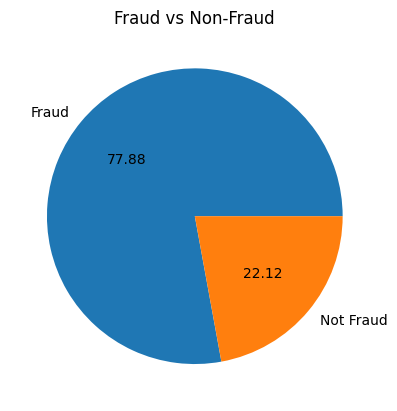

In [366]:
import matplotlib.pyplot as plt
plt.pie(df['Fraud'].value_counts(),labels=['Fraud','Not Fraud'], autopct="%0.2f")
plt.title("Fraud vs Non-Fraud")
plt.show()

In [367]:
df.sample(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),date(DD/MM/YYYY),amount(Rs.),Fraud
11388,verifypnf@upi,Requested,22:19,19/09/2019,193915,1
6631,rahulsharma@ybl,Debited,21:00,29/04/2021,112197,0
72365,kycojj@alert,Requested,13:41,19/12/2017,13293,1
23420,refundzyh@secure,Requested,00:56,16/07/2020,15561,1
18431,prizeowj@alert,Requested,03:24,13/10/2026,191701,1
44390,urgentbmx@upi,Debited,09:28,27/04/2026,125854,1
72115,prizeloq@alert,Debited,19:57,23/03/2018,133755,1


In [368]:
df.rename(columns={'date(DD/MM/YYYY)':'Date(DD/MM/YYYY)','amount(Rs.)':'Amount(Rs.)','Fraud':'is_Fraud'},inplace=True)
df.sample(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud
37589,flipkart@ybl,Debited,21:12,12/11/2018,84009,0
62662,amazonpay@ybl,Debited,05:06,10/08/2026,20167,0
20549,urgentggc@upi,Debited,10:17,11/11/2021,133423,1
63584,refundnll@alert,Debited,06:20,01/08/2016,50773,1
17734,kyckvl@alert,Debited,20:07,23/04/2017,13377,1
65650,verifyrxa@upi,Requested,06:33,08/07/2021,83610,1
20081,verifyygj@secure,Debited,16:13,28/07/2018,166479,1


In [369]:
df.duplicated().sum()
#If duplicates were there simply use-> df = df.drop_duplicates(keep='First')

np.int64(0)

In [370]:
df.shape

(87342, 6)

In [371]:
#Exploratory Data Analysis

In [372]:
#column names
#['receiver_upi_id','transaction_type','transaction_time(HH:MM)','date(DD/MM/YYYY)','amount(Rs.)','Fraud']
#receiver_upi_id -- text processing

In [373]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/kaka/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [374]:
#Number of characters in each UPI ID

In [375]:
df['num_char'] = df['receiver_upi_id'].apply(len)

In [376]:
df.head()

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14


In [377]:
#Number of words using nltk.word_tokenize(lambda_variable) && then calculate no. of words of each id after tokenize
df['num_words'] = df['receiver_upi_id'].apply(lambda x: len(nltk.word_tokenize(x)))
#all id should have 3 parts as xyz@abc -> [xyz,@,abc]

In [378]:
df.head()

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,num_words
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,3
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,3
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,3
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10,3
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14,3


In [379]:
#df['num_words'] = df['receiver_upi_id'].apply(lambda x: nltk.sent_tokenize(x))
#--> Number of sentences using nltk.sent_tokenize(lambda_variable) && then calculate how much sentences in a row

In [380]:
#description of values
df[['num_char','num_words']].describe()

,num_char,num_words
count,87342.000000,87342.0
mean,14.411257,3.0
std,2.317130,0.0
min,8.000000,3.0
25%,13.000000,3.0
50%,14.000000,3.0
75%,16.000000,3.0
max,24.000000,3.0


In [381]:
#Describes values for is_Fraud=0 : Fraud=No(Safe Transaction)
df[df['is_Fraud']==0][['num_char','num_words']].describe()

,num_char,num_words
count,19321.000000,19321.0
mean,14.802753,3.0
std,3.800793,0.0
min,8.000000,3.0
25%,12.000000,3.0
50%,15.000000,3.0
75%,18.000000,3.0
max,24.000000,3.0


In [382]:
#Describes values for is_Fraud=1 : Fraud=Yes(Not Safe Transaction)
df[df['is_Fraud']==1][['num_char','num_words']].describe()

,num_char,num_words
count,68021.000000,68021.0
mean,14.300054,3.0
std,1.653815,0.0
min,10.000000,3.0
25%,13.000000,3.0
50%,14.000000,3.0
75%,15.000000,3.0
max,18.000000,3.0


<Axes: xlabel='num_char', ylabel='Count'>

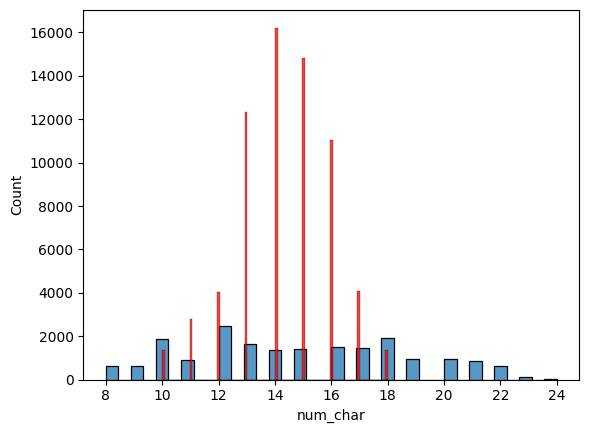

In [383]:
sns.histplot(df[df['is_Fraud']==0]['num_char'])
sns.histplot(df[df['is_Fraud']==1]['num_char'],color='Red')
#R-1: In fraud id: num_char is less but count high
#R-2: In non-fraud id: num_char is more but count is low
#Data Behavioural Representation

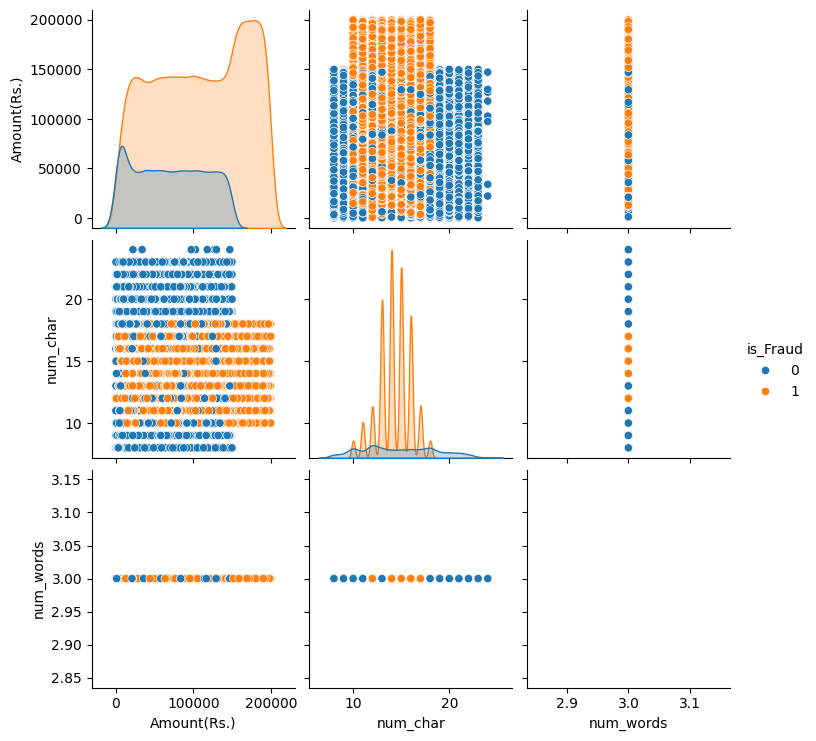

In [384]:
sns.pairplot(df,hue='is_Fraud') #Finds behavioural pattern

<Axes: >

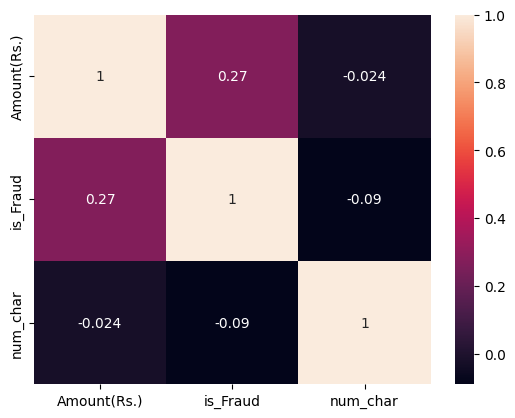

In [385]:
#Find correlation among the features(At first make all of these numeric values)
#Plot it into a heatmap 
df = df.drop(columns=['num_words'])
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [386]:
#Text : UPI ID preprocessing

In [387]:
#Convert abc@xyz -> abc xyz
def transform_text(text):
    text = text.lower() #LowerCase
    text = nltk.word_tokenize(text) #Word Split
    y=[] #Empty list
    for i in text:
        if i.isalnum():
            y.append(i) #Append except '@'
    return " ".join(y) #Return as a string, elements seperated with " "

In [388]:
transform_text(df['receiver_upi_id'][79])

'rewardyvn secure'

In [389]:
#Converts entire column into space seperated string without @
df['new_r_id'] = df['receiver_upi_id'].apply(transform_text) 

In [390]:
#Import wordcloud and make its object
#Syntax: objectWC = WordCloud(width=x,height=y,min_font_size=a,background_color='color_name')
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [391]:
df.head(3)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,amitsharma ybl
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,urgentxpo upi
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,supportgtc secure


In [392]:
#Generate Word Cloud to check significant keywords in upi id
#which are associated with Fraud Transactions("is_Fraud"==1)

In [393]:
#generate wc from ['new_r_id'] where is_Fraud=1, -> .str(converts to string) -> .cat(sep=" ")[Space Seperated]
fraud_wc = wc.generate(df[df['is_Fraud'] == 1]['new_r_id'].str.cat(sep=" "))

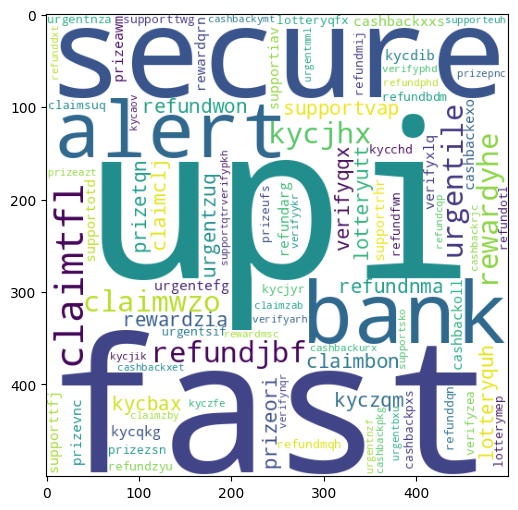

In [394]:
plt.figure(figsize=(15,6))
plt.imshow(fraud_wc)

In [395]:
#Generate Word Cloud to check significant keywords in upi id
#which are associated with Non-Fraud Transactions("is_Fraud"==0)

In [396]:
#generate wc from ['new_r_id'] where is_Fraud=0, -> .str(converts to string) -> .cat(sep=" ")[Space Seperated]
safe_wc = wc.generate(df[df['is_Fraud']==0]['new_r_id'].str.cat(sep=" "))

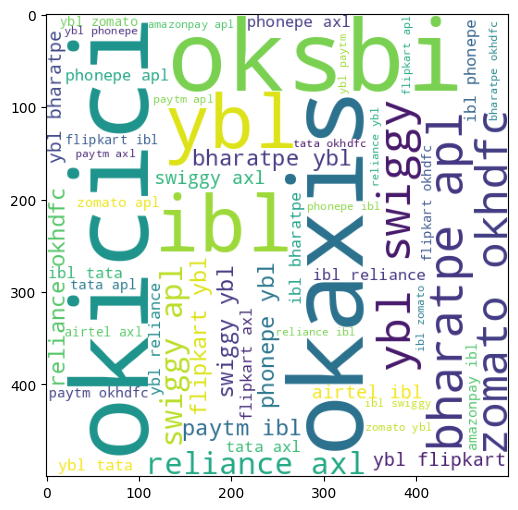

In [397]:
plt.figure(figsize=(15,6))
plt.imshow(safe_wc)

In [398]:
#For is_Fraud=1, convert each values from 'new_r_id' to a single list of Strings
list_1 = df[df['is_Fraud']==1]['new_r_id'].tolist()
fraud_corp=[]
#For each message string in list
for msg in list_1:
    #for each word in msg string
    for word in msg.split():
        fraud_corp.append(word) #Add all word elements of all msg elements in a single list

In [399]:
#total words associated with is_Fraud=1
len(fraud_corp)

136042

In [400]:
#Create a dictionary of the frequency of the words
from collections import Counter
#Finds most occured top 50 words with their frequencies --> store it in a dataframe
top_5_fraud_word = pd.DataFrame(Counter(fraud_corp).most_common(5))
top_5_fraud_word

,0,1
0,upi,13682
1,fast,13674
2,secure,13653
3,bank,13578
4,alert,13434


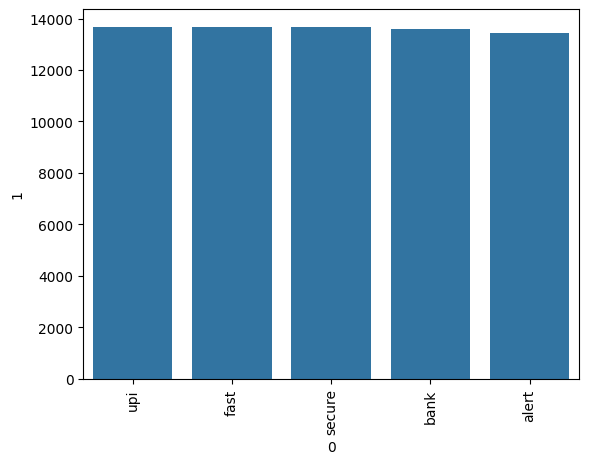

In [401]:
sns.barplot(x=top_5_fraud_word[0],y=top_5_fraud_word[1])
plt.xticks(rotation='vertical')
plt.show()

In [402]:
#For is_Fraud=0, convert each values from 'new_r_id' to a single list of Strings
list_2 = df[df['is_Fraud']==0]['new_r_id'].tolist()
safe_corp=[]
#For each message string in list
for msg in list_2:
    #for each word in msg string
    for word in msg.split():
        safe_corp.append(word) #Add all word elements of all msg elements in a single list

In [403]:
#total words associated with is_Fraud=0
len(safe_corp)

38642

In [404]:
#Create a dictionary of the frequency of the words
safe_dict = Counter(safe_corp)
#Finds most occured top 50 words with their frequencies --> store it in a dataframe
top_5_safe_word = pd.DataFrame(Counter(safe_corp).most_common(5))
top_5_safe_word

,0,1
0,ybl,3889
1,ibl,3793
2,oksbi,2346
3,okaxis,2257
4,okicici,2245


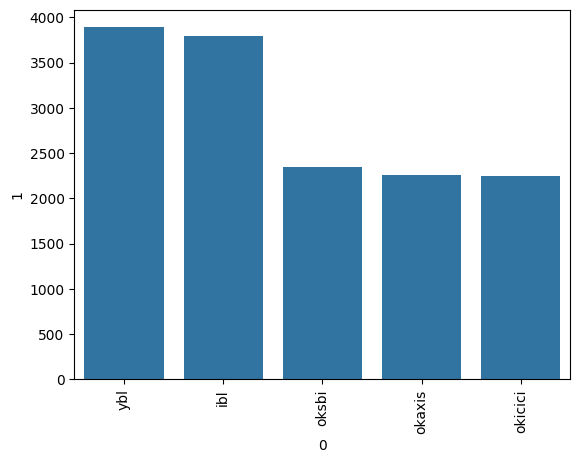

In [405]:
sns.barplot(x=top_5_safe_word[0],y=top_5_safe_word[1])
plt.xticks(rotation='vertical')
plt.show()

In [406]:
#Model Building

In [407]:
df.head(5)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,amitsharma ybl
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,urgentxpo upi
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,supportgtc secure
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10,kycgee upi
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14,prizeiva alert


In [413]:
df.head(5)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,amitsharma ybl
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,urgentxpo upi
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,supportgtc secure
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10,kycgee upi
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14,prizeiva alert


In [414]:
#It is an 1-D array with single single element, no need to make a new 1-D list
#Evaluating time when is_Fraud=1
fraud_time_corp = df[df['is_Fraud']==1]['transaction_time(HH:MM)'].tolist()
len(fraud_time_corp)

68021

In [415]:
top_30_fraud_time = pd.DataFrame(Counter(fraud_time_corp).most_common(30))
top_30_fraud_time
#DataFrame format: pd_var[0] = Value of element, pd_var[1] = Freq count of element

,0,1
0,21:41,73
1,09:57,70
2,02:44,69
3,16:24,68
4,06:51,68
5,23:51,66
6,14:03,66
7,13:57,66
8,06:33,66
9,01:53,65


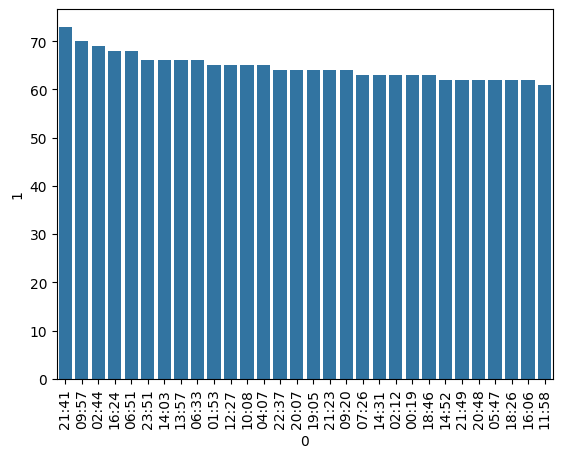

In [416]:
sns.barplot(x=top_30_fraud_time[0],y=top_30_fraud_time[1])
plt.xticks(rotation='vertical')
plt.show()

In [417]:
#It is an 1-D array with single single element, no need to make a new 1-D list
#Evaluating time when is_Fraud=0
safe_time_corp = df[df['is_Fraud']==0]['transaction_time(HH:MM)'].tolist()
len(safe_time_corp)

19321

In [418]:
top_30_safe_time = pd.DataFrame(Counter(safe_time_corp).most_common(30))
top_30_safe_time
#DataFrame format: pd_var[0] = Value of element, pd_var[1] = Freq count of element

,0,1
0,15:10,26
1,12:04,25
2,23:37,25
3,13:52,25
4,21:12,25
5,20:53,24
6,15:43,24
7,20:15,24
8,09:42,23
9,12:43,23


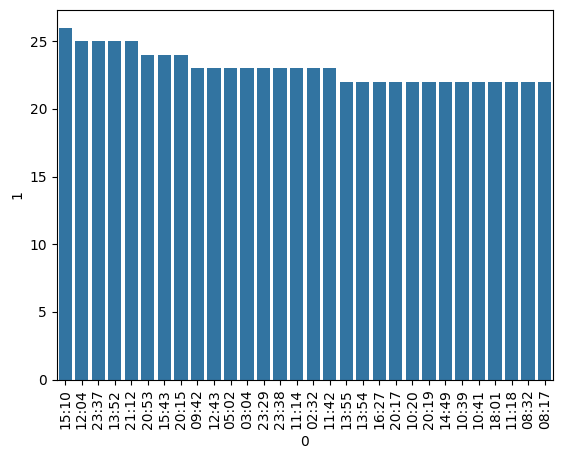

In [419]:
sns.barplot(x=top_30_safe_time[0],y=top_30_safe_time[1])
plt.xticks(rotation='vertical')
plt.show()

In [420]:
fraud_date_corp = df[df['is_Fraud']==1]['Date(DD/MM/YYYY)'].tolist()
len(fraud_date_corp)

68021

In [421]:
top_30_fraud_date = pd.DataFrame(Counter(fraud_date_corp).most_common(30))
top_30_fraud_date

,0,1
0,05/05/2018,36
1,23/07/2021,32
2,29/11/2018,32
3,02/04/2021,31
4,18/11/2020,30
5,11/10/2017,30
6,15/05/2022,30
7,07/07/2016,30
8,27/07/2018,30
9,07/06/2026,30


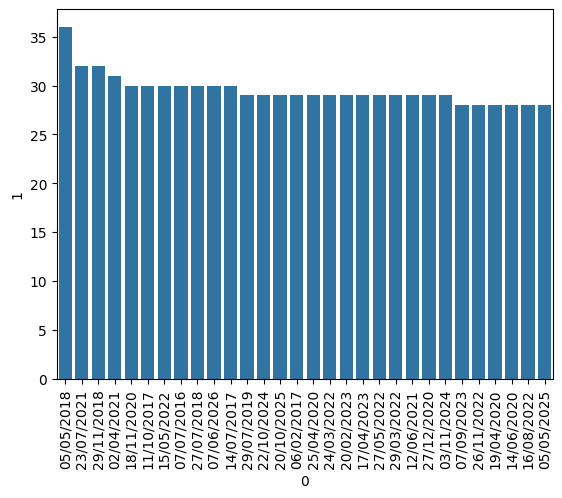

In [422]:
sns.barplot(x=top_30_fraud_date[0],y=top_30_fraud_date[1])
plt.xticks(rotation='vertical')
plt.show()

In [423]:
safe_date_corp = df[df['is_Fraud']==0]['Date(DD/MM/YYYY)'].tolist()
len(safe_date_corp)

19321

In [424]:
top_30_safe_date = pd.DataFrame(Counter(safe_date_corp).most_common(30))
top_30_safe_date

,0,1
0,06/03/2018,14
1,28/03/2022,13
2,20/01/2022,13
3,16/07/2026,12
4,13/08/2020,12
5,10/08/2019,12
6,15/04/2016,12
7,12/03/2020,12
8,31/10/2024,12
9,07/12/2023,12


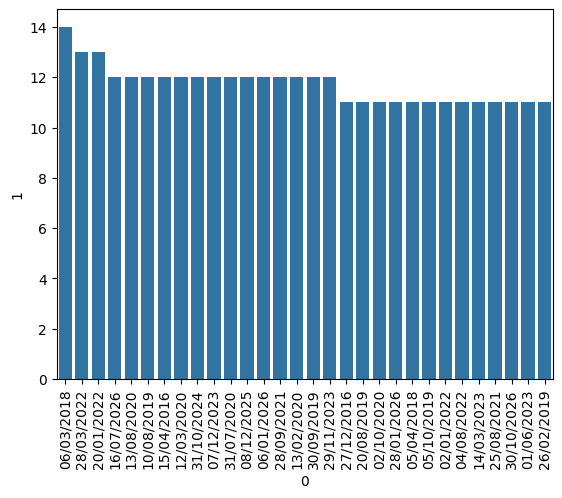

In [425]:
sns.barplot(x=top_30_safe_date[0],y=top_30_safe_date[1])
plt.xticks(rotation='vertical')
plt.show()

In [432]:
df.sample(3)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id,Date_mod,Time_mod,Type_mod
70826,cashbackspf@secure,Requested,17:23,30/09/2020,101994,1,18,cashbackspf secure,30092020,1723,1
17615,urgenttkh@secure,Requested,06:20,06/03/2025,136981,1,16,urgenttkh secure,6032025,620,1
69834,supporthys@secure,Requested,19:43,19/10/2025,188571,1,17,supporthys secure,19102025,1943,1


In [427]:
#Replaces date '/' : 01/01/2025 -> 01  01 2025
df['Date_mod'] = df['Date(DD/MM/YYYY)'].str.replace('/','').astype(int)

In [428]:
def transform_time(time):
    return int(time.replace(':',''))

In [429]:
df['Time_mod'] = df['transaction_time(HH:MM)'].apply(transform_time)

In [431]:
tr_label = LabelEncoder()
df['Type_mod'] = tr_label.fit_transform(df['transaction_type'])

In [434]:
df_numeric = df[['num_char','new_r_id','Date_mod','Time_mod','Type_mod','is_Fraud']]
df_numeric.sample(5)

,num_char,new_r_id,Date_mod,Time_mod,Type_mod,is_Fraud
9933,14,supporthnj upi,31072026,2123,1,1
17521,14,supportrzr upi,21072020,600,1,1
81989,13,urgentkye upi,5032025,1724,1,1
4377,14,refundbky fast,27062026,2113,1,1
24816,16,lotterybib alert,2072025,328,0,1


In [ ]:
#new_r_id vectorization from now on